## 1. Import Required Libraries

# Pepper Robot IK Interactive Solver Test
This notebook tests the inverse kinematics controller for the Pepper robot. You can interactively change the arm positions using sliders and visualize the resulting joint angles.

In [ ]:
import numpy as np
import os
import sys
import pandas as pd
from pathlib import Path

from ikpy.chain import Chain
from ikpy.utils import plot

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, FloatSlider, Output, VBox, HTML
import matplotlib.pyplot as plt

# Set up path to load chains
SCRIPT_DIR = Path('./server/pepper_ik_resources').resolve().parent
print(f"Working directory: {SCRIPT_DIR}")

Working directory: C:\Users\oscar\Documents\GitHub\Pepper-Imitation-System\01-server\dl-pose


## 2. Load Pepper Robot Chains

In [ ]:
# Load the Pepper robot chains from JSON files
resources_dir = Path('./server/pepper_ik_resources').resolve()

pepper_left_arm_chain = Chain.from_json_file(str(resources_dir / "pepper_left_arm.json"))
pepper_right_arm_chain = Chain.from_json_file(str(resources_dir / "pepper_right_arm.json"))
pepper_legs_chain = Chain.from_json_file(str(resources_dir / "pepper_legs.json"))
pepper_head_chain = Chain.from_json_file(str(resources_dir / "pepper_head.json"))

print("✓ Chains loaded successfully")
print(f"  Left arm joints: {len(pepper_left_arm_chain)}")
print(f"  Right arm joints: {len(pepper_right_arm_chain)}")
print(f"  Legs joints: {len(pepper_legs_chain)}")
print(f"  Head joints: {len(pepper_head_chain)}")

✓ Chains loaded successfully
  Left arm joints: 9
  Right arm joints: 9
  Legs joints: 7
  Head joints: 7


## 3. Visualize Robot Structure (Default Position)

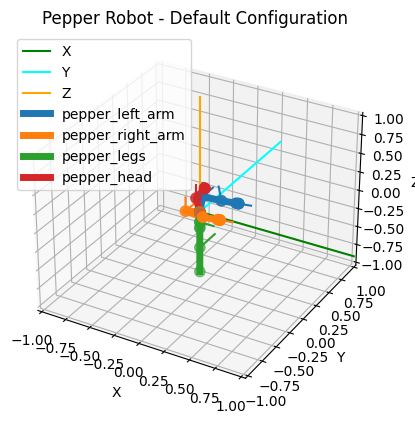

In [38]:
fig, ax = plot.init_3d_figure()
pepper_left_arm_chain.plot([0] * (len(pepper_left_arm_chain)), ax)
pepper_right_arm_chain.plot([0] * (len(pepper_right_arm_chain)), ax)
pepper_legs_chain.plot([0] * (len(pepper_legs_chain)), ax)
pepper_head_chain.plot([0] * (len(pepper_head_chain)), ax)
ax.legend()
plt.title("Pepper Robot - Default Configuration")
plt.show()

## 4. Interactive Inverse Kinematics Solver
Use the sliders below to move the left and right arm end-effectors. The IK solver will compute the required joint angles and display them.

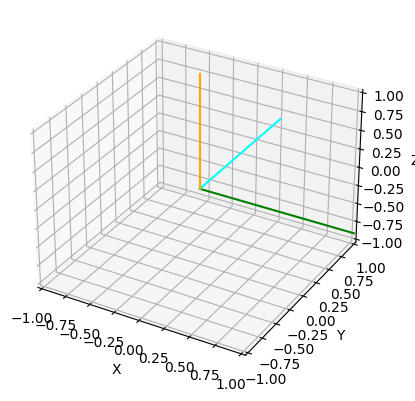

interactive(children=(FloatSlider(value=0.29704547692436817, description='Left X', max=0.7970454769243682, min…

<function __main__.goto_fixed(xl, yl, zl, xr, yr, zr)>

In [39]:
# Get initial position from forward kinematics
x2, y2, z2 = pepper_right_arm_chain.forward_kinematics([0] * (len(pepper_right_arm_chain)))[:3, 3]
size2 = 0.5

# Store angle history
angle_history_left2 = []
angle_history_right2 = []
position_history2 = []

# Create figure ONCE and reuse it
fig2, ax2 = plot.init_3d_figure()
xlim2 = ax2.get_xlim3d()
ylim2 = ax2.get_ylim3d()
zlim2 = ax2.get_zlim3d()

def goto_fixed(xl, yl, zl, xr, yr, zr):
    ax2.clear()
    
    # Right arm IK
    frame_target = np.eye(4)
    frame_target[:3, 3] = [xr, yr, zr]
    ik_right = pepper_right_arm_chain.inverse_kinematics_frame(frame_target, optimizer="scalar")

    print(f"IK solution for right arm: {ik_right}")

    pepper_right_arm_chain.plot(ik_right, ax2)
    
    # Left arm IK
    frame_target[:3, 3] = [xl, yl, zl]
    ik_left = pepper_left_arm_chain.inverse_kinematics_frame(frame_target, optimizer="scalar")
    pepper_left_arm_chain.plot(ik_left, ax2)
    
    # Plot legs and head
    pepper_legs_chain.plot([0] * (len(pepper_legs_chain)), ax2)
    pepper_head_chain.plot([0] * (len(pepper_head_chain)), ax2)
    
    # Manually plot target points without the 'target' parameter to avoid scatter plot conflict
    ax2.scatter([xl, xr], [yl, yr], [zl, zr], marker='x', s=200, c='red', linewidths=3, label='Targets')
    
    ax2.legend()
    ax2.set_xlabel('X (m)')
    ax2.set_ylabel('Y (m)')
    ax2.set_zlabel('Z (m)')
    
    # Store in history
    angle_history_left2.append(ik_left.copy())
    angle_history_right2.append(ik_right.copy())
    position_history2.append((xl, yl, zl, xr, yr, zr))
    
    # Print joint angles with names
    left_joint_names = [link.name for link in pepper_left_arm_chain.links[1:]]  # Skip base
    right_joint_names = [link.name for link in pepper_right_arm_chain.links[1:]]  # Skip base
    
    print("="*70)
    print(f"Target Position - Left: ({xl:.3f}, {yl:.3f}, {zl:.3f}), Right: ({xr:.3f}, {yr:.3f}, {zr:.3f})")
    print("-"*70)
    print("Left arm joint angles:")
    for i, (name, angle) in enumerate(zip(left_joint_names, ik_left)):
        print(f"  {name}: {angle:.4f} rad ({np.degrees(angle):.2f}°)")
    print("-"*70)
    print("Right arm joint angles:")
    for i, (name, angle) in enumerate(zip(right_joint_names, ik_right)):
        print(f"  {name}: {angle:.4f} rad ({np.degrees(angle):.2f}°)")
    print("="*70)
    
interact(goto_fixed,
         xl=FloatSlider(min=x2-size2, max=x2+size2, value=x2, step=0.01, description='Left X'),
         yl=FloatSlider(min=y2-size2, max=y2+size2, value=y2, step=0.01, description='Left Y'),
         zl=FloatSlider(min=z2-size2, max=z2+size2, value=z2, step=0.01, description='Left Z'),
         xr=FloatSlider(min=x2-size2, max=x2+size2, value=x2, step=0.01, description='Right X'),
         yr=FloatSlider(min=y2-size2, max=y2+size2, value=y2, step=0.01, description='Right Y'),
         zr=FloatSlider(min=z2-size2, max=z2+size2, value=z2, step=0.01, description='Right Z'))

In [40]:
print("🔧 RIGHT ARM CHAIN STRUCTURE WITH ANGLE BOUNDS")
print("="*80)
print(f"Total links in chain: {len(pepper_right_arm_chain)}")
print(f"\nLink details:")
for i, link in enumerate(pepper_right_arm_chain.links):
    if link.bounds is not None:
        bounds_deg = (np.degrees(link.bounds[0]), np.degrees(link.bounds[1]))
        print(f"  [{i}] {link.name:25s} | Bounds: [{bounds_deg[0]:7.2f}°, {bounds_deg[1]:7.2f}°]")
    else:
        print(f"  [{i}] {link.name:25s} | Bounds: None (fixed)")

print("\n" + "="*80)
print("JOINT ANGLE MAPPING:")
print("="*80)
joint_names = [link.name for link in pepper_right_arm_chain.links[1:]]  # Skip base
print(f"Angle array indices correspond to these joints:")
for idx, name in enumerate(joint_names):
    print(f"  angle_array[{idx}] = {name}")

print("\n" + "="*80)
print("Testing IK with FORCED non-zero initial guess:")
print("="*80)

# Get default position
x_default, y_default, z_default = pepper_right_arm_chain.forward_kinematics([0] * len(pepper_right_arm_chain))[:3, 3]
print(f"Default position: X={x_default:.4f}, Y={y_default:.4f}, Z={z_default:.4f}")

# Test 1: Small offset to the right (X)
target1 = np.eye(4)
target1[:3, 3] = [x_default + 0.1, y_default, z_default]

# Test with zero initial guess
print(f"\n--- Test 1: Target X+0.1m with ZERO initial guess ---")
ik1_zero = pepper_right_arm_chain.inverse_kinematics_frame(target1, optimizer="scalar")
print(f"All angles (degrees):")
for idx, (angle, name) in enumerate(zip(ik1_zero, joint_names)):
    print(f"  [{idx}] {name:25s}: {np.degrees(angle):7.2f}°")

# Test with non-zero initial guess biasing ShoulderPitch
print(f"\n--- Test 1b: Same target with NON-ZERO initial guess ---")
initial_guess = [0, 0, 0.5, 0.3, 0, 0, 0, 0, 0]  # Force various joints
ik1_nonzero = pepper_right_arm_chain.inverse_kinematics_frame(target1, optimizer="scalar", initial_position=initial_guess)
print(f"All angles (degrees):")
for idx, (angle, name) in enumerate(zip(ik1_nonzero, joint_names)):
    print(f"  [{idx}] {name:25s}: {np.degrees(angle):7.2f}°")

# Test 2: Target above head (should force vertical movement)
print(f"\n--- Test 2: Target HIGH above default (Z+0.3m) ---")
target2 = np.eye(4)
target2[:3, 3] = [x_default, y_default, z_default + 0.3]
ik2 = pepper_right_arm_chain.inverse_kinematics_frame(target2, optimizer="scalar")
print(f"All angles (degrees):")
for idx, (angle, name) in enumerate(zip(ik2, joint_names)):
    print(f"  [{idx}] {name:25s}: {np.degrees(angle):7.2f}°")

# Test 3: Target to the side (left)
print(f"\n--- Test 3: Target to the LEFT (Y-0.3m) ---")
target3 = np.eye(4)
target3[:3, 3] = [x_default, y_default - 0.3, z_default]
ik3 = pepper_right_arm_chain.inverse_kinematics_frame(target3, optimizer="scalar")
print(f"All angles (degrees):")
for idx, (angle, name) in enumerate(zip(ik3, joint_names)):
    print(f"  [{idx}] {name:25s}: {np.degrees(angle):7.2f}°")


🔧 RIGHT ARM CHAIN STRUCTURE WITH ANGLE BOUNDS
Total links in chain: 9

Link details:
  [0] Base link                 | Bounds: [   -inf°,     inf°]
  [1] base_link_fixedjoint      | Bounds: [   -inf°,     inf°]
  [2] RShoulderPitch            | Bounds: [-119.50°,  119.50°]
  [3] RShoulderRoll             | Bounds: [ -89.50°,   -0.50°]
  [4] RElbowYaw                 | Bounds: [-119.50°,  119.50°]
  [5] RElbowRoll                | Bounds: [   0.50°,   89.50°]
  [6] RWristYaw                 | Bounds: [-104.50°,  104.50°]
  [7] RHand                     | Bounds: [   1.15°,   56.15°]
  [8] last_joint                | Bounds: [   -inf°,     inf°]

JOINT ANGLE MAPPING:
Angle array indices correspond to these joints:
  angle_array[0] = base_link_fixedjoint
  angle_array[1] = RShoulderPitch
  angle_array[2] = RShoulderRoll
  angle_array[3] = RElbowYaw
  angle_array[4] = RElbowRoll
  angle_array[5] = RWristYaw
  angle_array[6] = RHand
  angle_array[7] = last_joint

Testing IK with FORCED non-

## 4.5 Chain Structure Inspection
Inspect the actual chain configuration to understand what's loaded.


In [41]:
print("🔍 PROPER ANGLE INDEXING - FILTERED BY CONTROLLABLE JOINTS")
print("="*80)

# Get default position
x_default, y_default, z_default = pepper_right_arm_chain.forward_kinematics([0] * len(pepper_right_arm_chain))[:3, 3]

# Test target
target = np.eye(4)
target[:3, 3] = [x_default + 0.1, y_default, z_default]

# Solve IK
ik_result = pepper_right_arm_chain.inverse_kinematics_frame(target, optimizer="scalar")

print(f"\nRaw IK result (length={len(ik_result)}):")
print(f"{ik_result}\n")

print("="*80)
print("Mapping to controllable joints:")
print("="*80)

controllable_joints = []
for idx, link in enumerate(pepper_right_arm_chain.links):
    angle = ik_result[idx] if idx < len(ik_result) else None
    
    # Check if this is a controllable joint (has bounds and not infinity)
    is_controllable = (link.bounds is not None and 
                      link.bounds[0] != float('-inf') and 
                      link.bounds[1] != float('inf'))
    
    if link.bounds is not None:
        bounds_deg = (np.degrees(link.bounds[0]), np.degrees(link.bounds[1]))
        bounds_str = f"[{bounds_deg[0]:7.2f}°, {bounds_deg[1]:7.2f}°]"
    else:
        bounds_str = "None (fixed)"
    
    if is_controllable:
        controllable_joints.append((idx, link.name, angle))
        status = "✓ CONTROLLABLE"
    else:
        status = "✗ FIXED"
    
    print(f"[{idx}] {link.name:25s} | Bounds: {bounds_str:30s} | Value: {np.degrees(angle) if angle else 0:7.2f}° | {status}")

print("\n" + "="*80)
print("ONLY CONTROLLABLE JOINTS (for motor control):")
print("="*80)
for idx, name, angle in controllable_joints:
    print(f"  Motor '{name}' (link[{idx}]): {np.degrees(angle):.2f}° ({angle:.6f} rad)")


🔍 PROPER ANGLE INDEXING - FILTERED BY CONTROLLABLE JOINTS

Raw IK result (length=9):
[ 0.          0.         -0.05980317 -0.00872665 -1.47805856  0.15705924
  0.          0.          0.        ]

Mapping to controllable joints:
[0] Base link                 | Bounds: [   -inf°,     inf°]           | Value:    0.00° | ✗ FIXED
[1] base_link_fixedjoint      | Bounds: [   -inf°,     inf°]           | Value:    0.00° | ✗ FIXED
[2] RShoulderPitch            | Bounds: [-119.50°,  119.50°]           | Value:   -3.43° | ✓ CONTROLLABLE
[3] RShoulderRoll             | Bounds: [ -89.50°,   -0.50°]           | Value:   -0.50° | ✓ CONTROLLABLE
[4] RElbowYaw                 | Bounds: [-119.50°,  119.50°]           | Value:  -84.69° | ✓ CONTROLLABLE
[5] RElbowRoll                | Bounds: [   0.50°,   89.50°]           | Value:    9.00° | ✓ CONTROLLABLE
[6] RWristYaw                 | Bounds: [-104.50°,  104.50°]           | Value:    0.00° | ✓ CONTROLLABLE
[7] RHand                     | Bounds: [  

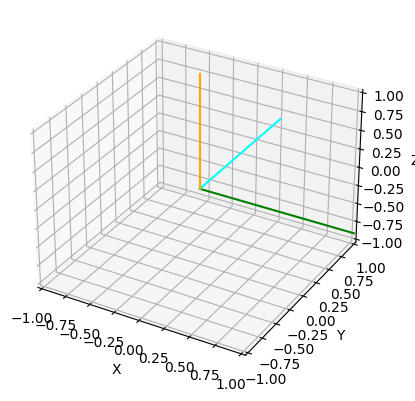

interactive(children=(FloatSlider(value=0.29704547692436817, description='Left X', max=0.7970454769243682, min…

In [45]:
# ============================================
# INTERACTIVE IK CONTROL (CONTROLLABLE ONLY)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# --------------------------------------------
# Initial position from FK
# --------------------------------------------
x0, y0, z0 = pepper_right_arm_chain.forward_kinematics(
    [0] * len(pepper_right_arm_chain)
)[:3, 3]

workspace_size = 0.5

# --------------------------------------------
# History storage
# --------------------------------------------
angle_history_left = []
angle_history_right = []
position_history = []

# --------------------------------------------
# Create figure ONCE
# --------------------------------------------
fig, ax = plot.init_3d_figure()

# --------------------------------------------
# Helper function
# --------------------------------------------
def print_controllable_joints(chain, ik_result, title="ARM"):

    print(f"\n{title}")
    print("-" * 90)

    controllable = []

    for idx, link in enumerate(chain.links):

        if idx >= len(ik_result):
            continue

        angle = ik_result[idx]

        # Detect controllable joints
        is_controllable = (
            link.bounds is not None and
            link.bounds[0] != float('-inf') and
            link.bounds[1] != float('inf')
        )

        if is_controllable:

            controllable.append((idx, link.name, angle))

            bounds_deg = (
                np.degrees(link.bounds[0]),
                np.degrees(link.bounds[1])
            )

            print(
                f"[{idx}] "
                f"{link.name:25s} | "
                f"{angle:+.4f} rad "
                f"({np.degrees(angle):+8.2f}°) | "
                f"Bounds: [{bounds_deg[0]:7.2f}°, {bounds_deg[1]:7.2f}°]"
            )

    return controllable

# --------------------------------------------
# Interactive IK function
# --------------------------------------------
def goto_controllable_only(xl, yl, zl, xr, yr, zr):

    ax.clear()

    # ========================================
    # RIGHT ARM IK
    # ========================================
    target_right = np.eye(4)
    target_right[:3, 3] = [xr, yr, zr]

    ik_right = pepper_right_arm_chain.inverse_kinematics_frame(
        target_right,
        optimizer="scalar"
    )

    # ========================================
    # LEFT ARM IK
    # ========================================
    target_left = np.eye(4)
    target_left[:3, 3] = [xl, yl, zl]

    ik_left = pepper_left_arm_chain.inverse_kinematics_frame(
        target_left,
        optimizer="scalar"
    )

    # ========================================
    # Plot robot
    # ========================================
    pepper_right_arm_chain.plot(ik_right, ax)
    pepper_left_arm_chain.plot(ik_left, ax)

    pepper_legs_chain.plot(
        [0] * len(pepper_legs_chain),
        ax
    )

    pepper_head_chain.plot(
        [0] * len(pepper_head_chain),
        ax
    )

    # ========================================
    # Plot targets
    # ========================================
    ax.scatter(
        [xl, xr],
        [yl, yr],
        [zl, zr],
        marker='x',
        s=200,
        c='red',
        linewidths=3,
        label='Targets'
    )

    ax.legend()

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')

    # ========================================
    # Store history
    # ========================================
    angle_history_left.append(ik_left.copy())
    angle_history_right.append(ik_right.copy())

    position_history.append(
        (xl, yl, zl, xr, yr, zr)
    )

    # ========================================
    # Print info
    # ========================================
    print("=" * 90)
    print("TARGET POSITIONS")
    print(f"Left :  ({xl:.3f}, {yl:.3f}, {zl:.3f})")
    print(f"Right:  ({xr:.3f}, {yr:.3f}, {zr:.3f})")
    print("=" * 90)

    print_controllable_joints(
        pepper_left_arm_chain,
        ik_left,
        title="LEFT ARM - CONTROLLABLE JOINTS"
    )

    print_controllable_joints(
        pepper_right_arm_chain,
        ik_right,
        title="RIGHT ARM - CONTROLLABLE JOINTS"
    )

    print("=" * 90)

# --------------------------------------------
# Interactive sliders
# --------------------------------------------
interact(
    goto_controllable_only,

    xl=FloatSlider(
        min=x0 - workspace_size,
        max=x0 + workspace_size,
        value=x0,
        step=0.01,
        description='Left X'
    ),

    yl=FloatSlider(
        min=y0 - workspace_size,
        max=y0 + workspace_size,
        value=y0,
        step=0.01,
        description='Left Y'
    ),

    zl=FloatSlider(
        min=z0 - workspace_size,
        max=z0 + workspace_size,
        value=z0,
        step=0.01,
        description='Left Z'
    ),

    xr=FloatSlider(
        min=x0 - workspace_size,
        max=x0 + workspace_size,
        value=x0,
        step=0.01,
        description='Right X'
    ),

    yr=FloatSlider(
        min=y0 - workspace_size,
        max=y0 + workspace_size,
        value=y0,
        step=0.01,
        description='Right Y'
    ),

    zr=FloatSlider(
        min=z0 - workspace_size,
        max=z0 + workspace_size,
        value=z0,
        step=0.01,
        description='Right Z'
    )
);

## 5. Plot Joint Angles Over Position Changes
Track how joint angles change as you move the end-effectors through different positions.

📊 Plotting Joint Angle Statistics
✓ Data loaded from interactive sliders


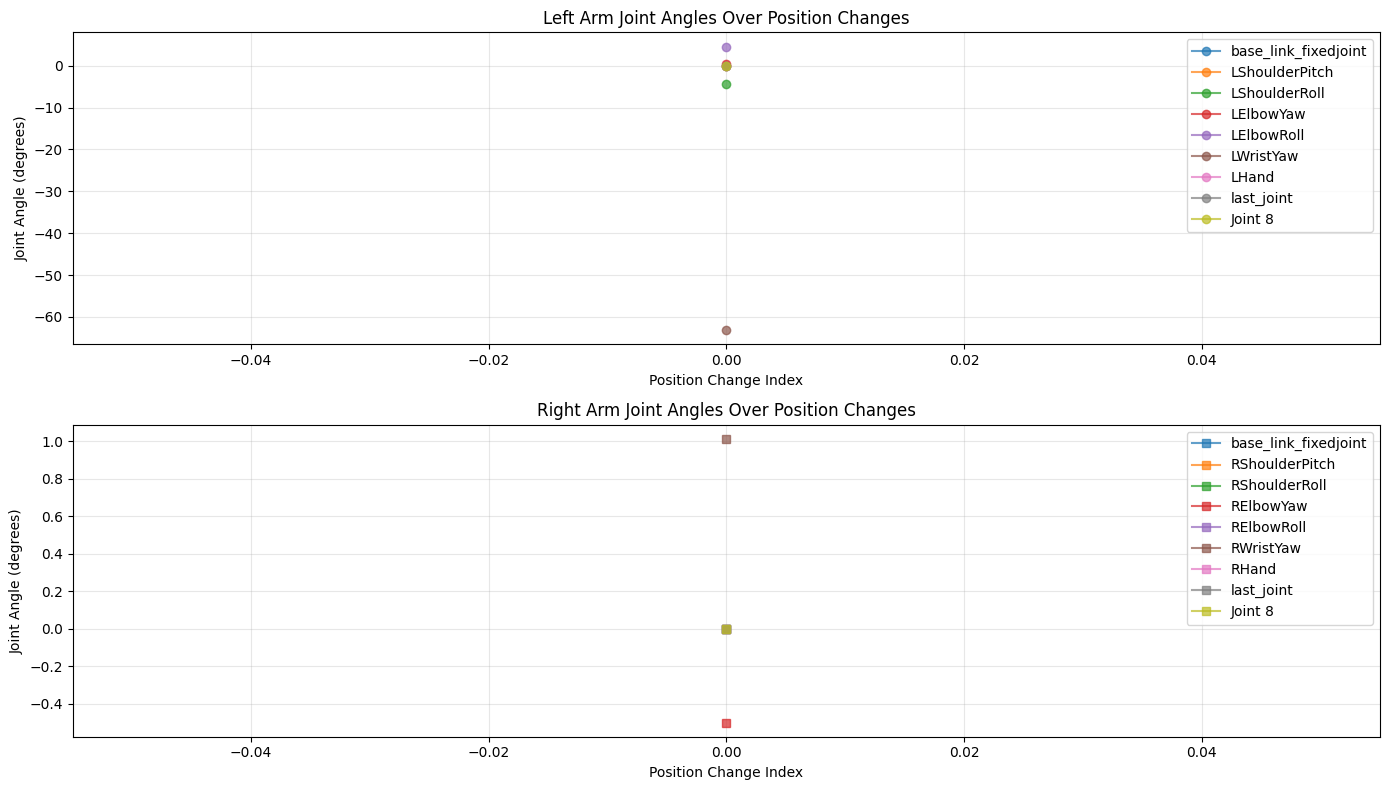


📊 Joint Angle Statistics

Left Arm:
  base_link_fixedjoint: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  LShoulderPitch: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  LShoulderRoll: min=-4.40°, max=-4.40°, mean=-4.40°, std=0.00°
  LElbowYaw: min=0.50°, max=0.50°, mean=0.50°, std=0.00°
  LElbowRoll: min=4.58°, max=4.58°, mean=4.58°, std=0.00°
  LWristYaw: min=-63.13°, max=-63.13°, mean=-63.13°, std=0.00°
  LHand: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  last_joint: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  Joint 8: min=0.00°, max=0.00°, mean=0.00°, std=0.00°

Right Arm:
  base_link_fixedjoint: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  RShoulderPitch: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  RShoulderRoll: min=0.00°, max=0.00°, mean=0.00°, std=0.00°
  RElbowYaw: min=-0.50°, max=-0.50°, mean=-0.50°, std=0.00°
  RElbowRoll: min=-0.00°, max=-0.00°, mean=-0.00°, std=0.00°
  RWristYaw: min=1.01°, max=1.01°, mean=1.01°, std=0.00°
  RHand: min=0.00°, max=0.00°, mean=0.00°, s

In [43]:
print("📊 Plotting Joint Angle Statistics")
print("="*70)

# Check if history has data
if len(angle_history_left2) > 0:
    angles_left = np.array(angle_history_left2)
    angles_right = np.array(angle_history_right2)
    print("✓ Data loaded from interactive sliders")
else:
    print("⚠️  No angle history recorded. Please use the interactive sliders above to collect data.")
    angles_left = None
    angles_right = None

if angles_left is not None and angles_right is not None:
    # Create plots for joint angle changes
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Left arm angles
    left_joint_names = [link.name for link in pepper_left_arm_chain.links[1:]]  # Skip base
    ax = axes[0]
    for i in range(angles_left.shape[1]):
        joint_name = left_joint_names[i] if i < len(left_joint_names) else f"Joint {i}"
        ax.plot(np.degrees(angles_left[:, i]), marker='o', label=joint_name, alpha=0.7)
    ax.set_title('Left Arm Joint Angles Over Position Changes')
    ax.set_xlabel('Position Change Index')
    ax.set_ylabel('Joint Angle (degrees)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Right arm angles
    right_joint_names = [link.name for link in pepper_right_arm_chain.links[1:]]  # Skip base
    ax = axes[1]
    for i in range(angles_right.shape[1]):
        joint_name = right_joint_names[i] if i < len(right_joint_names) else f"Joint {i}"
        ax.plot(np.degrees(angles_right[:, i]), marker='s', label=joint_name, alpha=0.7)
    ax.set_title('Right Arm Joint Angles Over Position Changes')
    ax.set_xlabel('Position Change Index')
    ax.set_ylabel('Joint Angle (degrees)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics with joint names
    left_joint_names = [link.name for link in pepper_left_arm_chain.links[1:]]  # Skip base
    right_joint_names = [link.name for link in pepper_right_arm_chain.links[1:]]  # Skip base
    
    print("\n📊 Joint Angle Statistics")
    print("="*70)
    print("\nLeft Arm:")
    for i in range(angles_left.shape[1]):
        angles_deg = np.degrees(angles_left[:, i])
        joint_name = left_joint_names[i] if i < len(left_joint_names) else f"Joint {i}"
        print(f"  {joint_name}: min={angles_deg.min():.2f}°, max={angles_deg.max():.2f}°, mean={angles_deg.mean():.2f}°, std={angles_deg.std():.2f}°")
    
    print("\nRight Arm:")
    for i in range(angles_right.shape[1]):
        angles_deg = np.degrees(angles_right[:, i])
        joint_name = right_joint_names[i] if i < len(right_joint_names) else f"Joint {i}"
        print(f"  {joint_name}: min={angles_deg.min():.2f}°, max={angles_deg.max():.2f}°, mean={angles_deg.mean():.2f}°, std={angles_deg.std():.2f}°")


In [44]:
print("📊 TESTS 1-3 WITH PROPER ANGLE INDEXING (Filtered by Controllable Joints)")
print("="*80)

# Get default position
x_default, y_default, z_default = pepper_right_arm_chain.forward_kinematics([0] * len(pepper_right_arm_chain))[:3, 3]
print(f"Default position: X={x_default:.4f}, Y={y_default:.4f}, Z={z_default:.4f}\n")

# Test targets (same as before)
test_targets = [
    ("Test 1: X+0.1m", [x_default + 0.1, y_default, z_default]),
    ("Test 2: Z+0.3m (HIGH)", [x_default, y_default, z_default + 0.3]),
    ("Test 3: Y-0.3m (LEFT)", [x_default, y_default - 0.3, z_default]),
]

for test_name, target_pos in test_targets:
    print("="*80)
    print(f"🎯 {test_name}")
    print("="*80)
    
    # Create target frame
    target = np.eye(4)
    target[:3, 3] = target_pos
    
    # Solve IK
    ik_result = pepper_right_arm_chain.inverse_kinematics_frame(target, optimizer="scalar")
    
    print(f"Target position: X={target_pos[0]:.4f}, Y={target_pos[1]:.4f}, Z={target_pos[2]:.4f}\n")
    
    # Print controllable joints only
    print("Controllable Joints:")
    print("-"*80)
    for idx, link in enumerate(pepper_right_arm_chain.links):
        angle = ik_result[idx] if idx < len(ik_result) else None
        
        # Check if this is a controllable joint
        is_controllable = (link.bounds is not None and 
                          link.bounds[0] != float('-inf') and 
                          link.bounds[1] != float('inf'))
        
        if is_controllable:
            print(f"  [{idx}] {link.name:25s}: {np.degrees(angle):7.2f}° ({angle:.6f} rad)")
    
    print()


📊 TESTS 1-3 WITH PROPER ANGLE INDEXING (Filtered by Controllable Joints)
Default position: X=0.2970, Y=-0.1647, Z=0.1143

🎯 Test 1: X+0.1m
Target position: X=0.3970, Y=-0.1647, Z=0.1143

Controllable Joints:
--------------------------------------------------------------------------------
  [2] RShoulderPitch           :   -3.43° (-0.059803 rad)
  [3] RShoulderRoll            :   -0.50° (-0.008727 rad)
  [4] RElbowYaw                :  -84.69° (-1.478059 rad)
  [5] RElbowRoll               :    9.00° (0.157059 rad)
  [6] RWristYaw                :    0.00° (0.000000 rad)
  [7] RHand                    :    0.00° (0.000000 rad)

🎯 Test 2: Z+0.3m (HIGH)
Target position: X=0.2970, Y=-0.1647, Z=0.4143

Controllable Joints:
--------------------------------------------------------------------------------
  [2] RShoulderPitch           :  -42.73° (-0.745755 rad)
  [3] RShoulderRoll            :   -0.50° (-0.008727 rad)
  [4] RElbowYaw                :  -84.88° (-1.481373 rad)
  [5] RElbowRoll 